# Species-by-channel decomposition (emissions-based)

This reads `004_run_magicc_emissions_based.py`/
`005_emissions_based_decomposition.py`'s `fixed_`-prefixed output - i.e. 
leave-one-out runs supplied emissions from 1751 and given the CH4/N2O "hardwired 
history" budget-closure re-anchoring wherever that gas isn't itself switched.

The "Burden-based total" reference marker (CH4 only) comes from `002`'s own
burden-based output. Output files are prefixed `fixed_`.

The opposite pivot from `007` (which asks, for one channel, how much comes from each
precursor). This one asks, for one species (NOx, CH4), how much of *its own* net
leave-one-out GSAT effect runs through each forcing channel - the same condensed
cross-scenario stacked-bar view `003` already computes per-scenario horizontal bar
charts for, just reshaped into `006`'s summary-plot styling
(`ac.plot_scenario_year_stacked_bars`) so scenarios sit side by side. No new MAGICC
runs - reads `004`'s direct leave-one-out totals and `005`'s already-computed QEXTRA
channel GSAT output.

Only NOx and CH4 here (not CO/VOC/N2O) - NOx and CH4 are the two species with the
richest channel sets (CH4 itself has 5 channels including its own cross-effect on
F-Gases/Montreal Halogens; NOx has 6 including its nitrate-aerosol-forming pathway).

**Expect a small residual** between "Sum of attributed channels" and the species' own
direct leave-one-out total - same non-additivity family documented throughout this
project: summing channels measured in isolation misses cross-channel/self-reinforcing 
feedbacks (e.g. CH4's own atmospheric-lifetime feedback) that only show up when everything 
runs together.

**Third reference marker, where available**: CH4 also gets a "Burden-based GSAT
contribution" marker - MAGICC's burden-based decomposition (`002`) isolates CH4 on
its own (it has its own standalone ERF variable in the real run), giving an
independent, single-run measurement of CH4's contribution to compare against the two
emissions-based numbers. NOx gets no such marker - burden-based can't isolate NOx at
all (it's pooled into the two Aerosol ERF variables together with SOx/NH3/BC/OC, and
into the single Tropospheric Ozone variable together with VOC/CO/CH4), so there is no
"NOx-only" burden-based channel to plot.

## Imports

In [2]:
from pathlib import Path

from pandas_openscm.db import FeatherDataBackend, FeatherIndexBackend, OpenSCMDB

import attribution_common as ac

## Configuration

In [3]:
EMBARGOED = True
"""Set True once running against real (embargoed) ScenarioMIP scenarios. Must match
004's/005's own EMBARGOED setting, since this notebook reads their output directly."""
DATA_DIR = Path("../data/embargoed") if EMBARGOED else Path("../data")

BASE_SCENARIOS = ac.load_base_scenarios(DATA_DIR)
"""Auto-discovered from 001's base_scenarios.json manifest."""

SWITCH_YEAR = 1750
"""Must match 004's SWITCH_YEAR - used to reconstruct each species' counterfactual
scenario name."""

YEARS_TO_PLOT = [2050, 2100]
BASELINE_YEAR = 2025
REGION = ac.REGION

OUTPUT_PREFIX = "fixed_"
"""Prepended to every plot filename below."""

EMISSIONS_CHANNEL_GSAT_DB_DIR = DATA_DIR / "fixed_emissions_channel_gsat_db"
"""005's `fixed_`-prefixed QEXTRA channel GSAT output, one scenario per (base_scenario,
species, channel) - already computed there, nothing new to run."""

BURDEN_GSAT_DB_DIR = DATA_DIR / "consistent_burden_gsat_db"
"""002's own QEXTRA channel GSAT output - a *third*, independent measurement of a
species' own contribution, where one exists (see BURDEN_AVAILABLE_CHANNEL below)."""

PLOTS_DIR = Path("../data/plots")
"""Always plain data/plots/, regardless of EMBARGOED - plots are not considered
sensitive, only raw emissions/MAGICC output."""
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

CORE_CATEGORIES = {
    "Tropospheric Ozone": "Effective Radiative Forcing|Tropospheric Ozone",
    "CH4": "Effective Radiative Forcing|CH4",
    "Stratospheric H2O": "Effective Radiative Forcing|CH4 Oxidation Stratospheric H2O",
}
HFC_CATEGORIES = {
    "F-Gases": "Effective Radiative Forcing|F-Gases",
    "Montreal Protocol Halogen Gases": "Effective Radiative Forcing|Montreal Protocol Halogen Gases",
}
AEROSOL_CATEGORIES = {
    "Aerosol Direct": "Effective Radiative Forcing|Aerosols|Direct Effect",
    "Aerosol Indirect": "Effective Radiative Forcing|Aerosols|Indirect Effect",
}

SPECIES_CATEGORIES = {
    "NOx": {**CORE_CATEGORIES, "N2O": "Effective Radiative Forcing|N2O", **AEROSOL_CATEGORIES},
    "CH4": {**CORE_CATEGORIES, **HFC_CATEGORIES},
}
"""Must match 005's NOX_CATEGORIES / (CORE_CATEGORIES + HFC_CATEGORIES) for CH4 - kept in
sync manually since it's a config constant, not shared machinery."""

BUCKET_COLORS = {
    species: dict(zip(categories.keys(), ac.CATEGORICAL_PALETTE)) for species, categories in SPECIES_CATEGORIES.items()
}
"""Fixed categorical order per species (see attribution_common.py's CATEGORICAL_PALETTE) -
each species has its own distinct channel set, so colors are assigned independently per
species, not shared across the two plots."""

BURDEN_AVAILABLE_CHANNEL = {"CH4": "CH4"}
"""Species -> the 002 FORCING_CATEGORIES channel label giving that species' own
burden-based GSAT contribution, where MAGICC's burden-based decomposition can actually
isolate it as its own channel. CH4 has its own standalone ERF variable in the real run,
so this exists for CH4. NOx has no entry - burden-based can't isolate NOx on its own at
all (it's pooled into the two Aerosol ERF variables together with SOx/NH3/BC/OC, and
into the single Tropospheric Ozone variable together with VOC/CO/CH4) - there is no
"NOx-only" burden-based channel to compare against."""

'Species -> the 002 FORCING_CATEGORIES channel label giving that species\' own\nburden-based GSAT contribution, where MAGICC\'s burden-based decomposition can actually\nisolate it as its own channel. CH4 has its own standalone ERF variable in the real run,\nso this exists for CH4. NOx has no entry - burden-based can\'t isolate NOx on its own at\nall (it\'s pooled into the two Aerosol ERF variables together with SOx/NH3/BC/OC, and\ninto the single Tropospheric Ozone variable together with VOC/CO/CH4) - there is no\n"NOx-only" burden-based channel to compare against.'

In [3]:
BUCKET_COLORS = {
    
'NOx': {
  'CH4': 'LightSkyBlue',
  'Stratospheric H2O': '#1baf7a',
  'Aerosol Direct': 'purple',
  'Tropospheric Ozone': 'yellow',
  'N2O': '#eda100',
  'Aerosol Indirect': '#B19CD9'},
    
'CH4': {
  'CH4': 'LightSkyBlue',
  'Tropospheric Ozone': 'yellow',
  'Stratospheric H2O': 'magenta',
  'F-Gases': 'blue',
  'Montreal Protocol Halogen Gases': 'cyan'}

}

## Load each species' direct leave-one-out output (203) and channel GSAT output (204)

In [4]:
def emissions_db_dir(species_key):
    """004's `fixed_`-prefixed dirs."""
    return DATA_DIR / f"fixed_emissions_scm_output_db_{ac.slugify(species_key)}"


def counterfactual_scenario_name(base_scenario, species_key):
    return f"{base_scenario}_no_{species_key}_{SWITCH_YEAR}"


def driving_scenario_name(base_scenario, species_key):
    """Matches 204's driving_scenario_name = f"{base_scenario}_{species_key}" naming."""
    return f"{base_scenario}_{species_key}"


species_output = {
    species_key: OpenSCMDB(
        backend_data=FeatherDataBackend(), backend_index=FeatherIndexBackend(), db_dir=emissions_db_dir(species_key)
    ).load(out_columns_type=int)
    for species_key in SPECIES_CATEGORIES
}
for df in species_output.values():
    df.columns.name = "year"

emissions_channel_gsat = OpenSCMDB(
    backend_data=FeatherDataBackend(), backend_index=FeatherIndexBackend(), db_dir=EMISSIONS_CHANNEL_GSAT_DB_DIR
).load(out_columns_type=int)
emissions_channel_gsat.columns.name = "year"
emissions_channel_gsat = emissions_channel_gsat.loc[
    (emissions_channel_gsat.index.get_level_values("variable") == "Surface Air Temperature Change")
    & (emissions_channel_gsat.index.get_level_values("region") == REGION)
]


def total_species_gsat_series(base_scenario, species_key, year):
    counterfactual = counterfactual_scenario_name(base_scenario, species_key)
    delta = ac.compute_delta(
        species_output[species_key], base_scenario, counterfactual, "Surface Air Temperature Change", region=REGION
    )
    return delta[year]


def channel_gsat_series(base_scenario, species_key, channel_label, year):
    scenario = f"{driving_scenario_name(base_scenario, species_key)}_forcing_only_{channel_label}"
    mask = emissions_channel_gsat.index.get_level_values("scenario") == scenario
    return ac.member_series(emissions_channel_gsat.loc[mask], year)


burden_gsat_by_channel = OpenSCMDB(
    backend_data=FeatherDataBackend(), backend_index=FeatherIndexBackend(), db_dir=BURDEN_GSAT_DB_DIR
).load(out_columns_type=int)
burden_gsat_by_channel.columns.name = "year"
burden_gsat_by_channel = burden_gsat_by_channel.loc[
    (burden_gsat_by_channel.index.get_level_values("variable") == "Surface Air Temperature Change")
    & (burden_gsat_by_channel.index.get_level_values("region") == REGION)
]


def burden_species_gsat_series(base_scenario, channel_label, year):
    """Deliberately NOT rebased to 1850-1900. This value is only ever used as a
    third comparison point alongside `total_species_gsat_series`/`channel_gsat_series`
    above (both emissions-based leave-one-out deltas, un-rebased) in the additivity
    check and the plot's reference markers. Rebasing only this marker would inject a
    spurious, non-cancelling offset (roughly this channel's own 1850-1900 mean) into
    that comparison."""
    scenario = f"{base_scenario}_forcing_only_{channel_label}"
    mask = burden_gsat_by_channel.index.get_level_values("scenario") == scenario
    return ac.member_series(burden_gsat_by_channel.loc[mask], year)

## Compute per-(scenario, year) channel contributions and reference markers, per species

Member-level discipline throughout: sum the channels' per-member GSAT series first
(aligned on `run_id`), *then* take the median - never `sum(median(a), median(b), ...)`.

In [5]:
species_bucket_values = {}
species_reference_markers_values = {}

for species_key, categories in SPECIES_CATEGORIES.items():
    bucket_values = {c: {} for c in categories}
    reference_markers_values = {"Total species GSAT": {}, "Sum of attributed": {}}
    if species_key in BURDEN_AVAILABLE_CHANNEL:
        reference_markers_values["Burden-based total"] = {}

    for base_scenario in BASE_SCENARIOS:
        short_name = ac.scenario_short_name(base_scenario)
        for year in YEARS_TO_PLOT:
            channel_series = {c: channel_gsat_series(base_scenario, species_key, c, year) for c in categories}
            for c in categories:
                bucket_values[c][(short_name, year)] = channel_series[c].median()

            all_channels_sum = sum(channel_series.values())
            reference_markers_values["Sum of attributed"][(short_name, year)] = all_channels_sum.median()
            reference_markers_values["Total species GSAT"][(short_name, year)] = total_species_gsat_series(
                base_scenario, species_key, year
            ).median()
            if species_key in BURDEN_AVAILABLE_CHANNEL:
                reference_markers_values["Burden-based total"][(short_name, year)] = burden_species_gsat_series(
                    base_scenario, BURDEN_AVAILABLE_CHANNEL[species_key], year
                ).median()

    species_bucket_values[species_key] = bucket_values
    species_reference_markers_values[species_key] = reference_markers_values

## Additivity spot-check

In [6]:
for species_key in SPECIES_CATEGORIES:
    reference_markers_values = species_reference_markers_values[species_key]
    for base_scenario in BASE_SCENARIOS:
        short_name = ac.scenario_short_name(base_scenario)
        for year in YEARS_TO_PLOT:
            attributed = reference_markers_values["Sum of attributed"][(short_name, year)]
            total = reference_markers_values["Total species GSAT"][(short_name, year)]
            line = (
                f"{species_key} {short_name} {year}: sum of attributed={attributed:+.4f} K, "
                f"total={total:+.4f} K, residual={attributed - total:+.4f} K"
            )
            if species_key in BURDEN_AVAILABLE_CHANNEL:
                burden = reference_markers_values["Burden-based total"][(short_name, year)]
                line += f", burden-based={burden:+.4f} K (vs. total: {burden - total:+.4f} K)"
            print(line)
    print()

NOx vl 2050: sum of attributed=+0.0625 K, total=+0.0544 K, residual=+0.0081 K
NOx vl 2100: sum of attributed=+0.1733 K, total=+0.1865 K, residual=-0.0132 K
NOx l 2050: sum of attributed=+0.0188 K, total=+0.0014 K, residual=+0.0174 K
NOx l 2100: sum of attributed=+0.0786 K, total=+0.0708 K, residual=+0.0078 K
NOx ln 2050: sum of attributed=+0.0220 K, total=+0.0067 K, residual=+0.0154 K
NOx ln 2100: sum of attributed=+0.0945 K, total=+0.0917 K, residual=+0.0028 K
NOx m 2050: sum of attributed=+0.0295 K, total=+0.0166 K, residual=+0.0129 K
NOx m 2100: sum of attributed=+0.0376 K, total=+0.0283 K, residual=+0.0093 K
NOx ml 2050: sum of attributed=+0.0241 K, total=+0.0101 K, residual=+0.0141 K
NOx ml 2100: sum of attributed=+0.0797 K, total=+0.0778 K, residual=+0.0018 K
NOx h 2050: sum of attributed=+0.0309 K, total=+0.0173 K, residual=+0.0136 K
NOx h 2100: sum of attributed=+0.0395 K, total=+0.0238 K, residual=+0.0156 K
NOx hl 2050: sum of attributed=+0.0178 K, total=+0.0011 K, residual=+0

## Plot: GSAT contribution by channel, per species

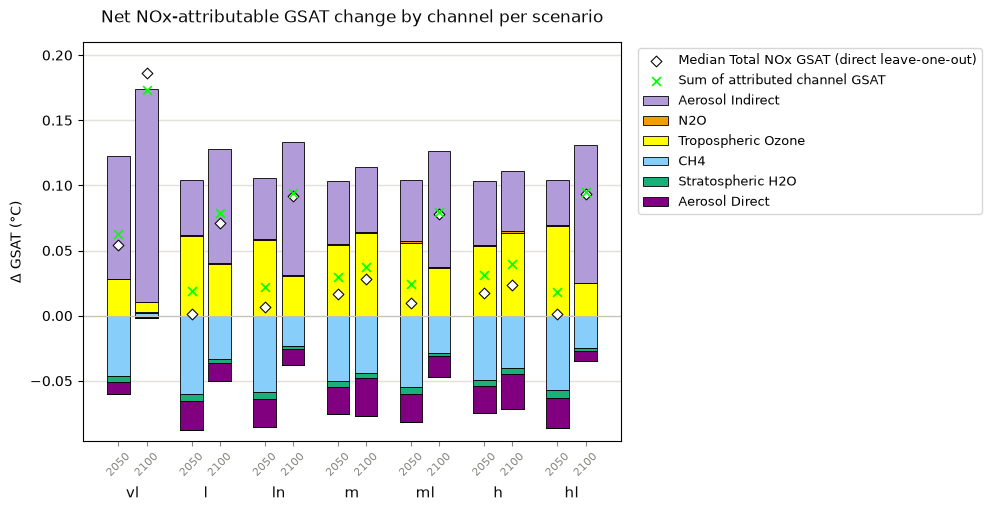

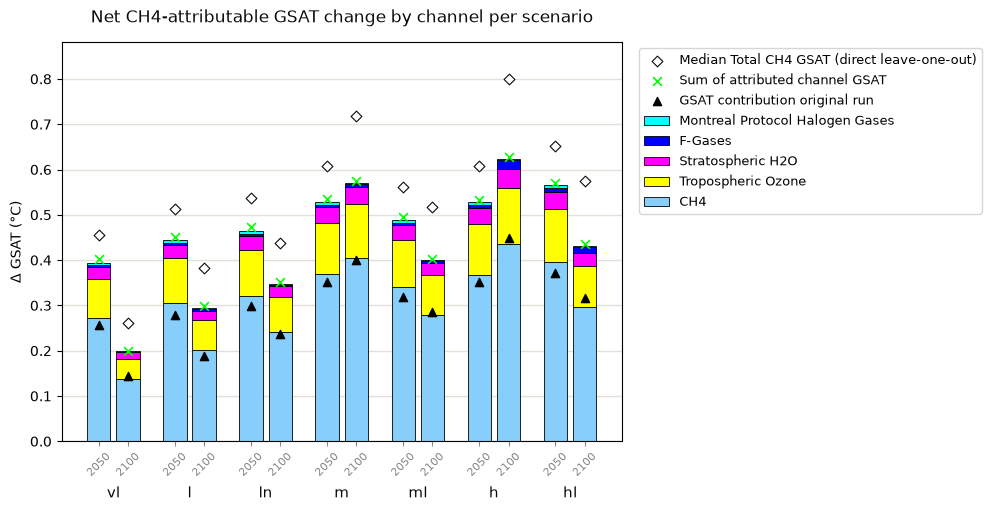

In [7]:
def fix_mixed_sign_legend_order(fig, ax, bucket_colors, bucket_values, reference_markers, out_path):
    """`ac.plot_scenario_year_stacked_bars`'s own legend is a flat reversed-dict-order
    list with no awareness of sign - that only matches the stack's visual
    top-to-bottom reading when every bucket is the same sign (true for CH4's channels,
    not for NOx's, which mixes positive GHG/ozone channels with negative aerosol
    channels: moving a negative bucket later in `bucket_colors` pushes it further
    *below* zero in the stack, but still higher up in a plain reversed-dict-order
    legend - the two rules point opposite ways for negative buckets). Rebuilt here
    instead, ordered by each bucket's own actual stacking position: positive buckets
    top-of-stack-to-bottom (reversed dict order - already correct for positive-only
    sets, e.g. CH4, so this is a no-op there), then negative buckets
    closest-to-zero-to-farthest (dict order, unreversed). Reference markers keep their
    existing "on top" position. Scoped to this notebook's two stacked-bar plots only -
    not a change to the shared function itself."""
    handles, labels = ax.get_legend_handles_labels()
    seen = {}
    for h, l in zip(handles, labels):
        if l not in seen:
            seen[l] = h

    def is_negative(bucket_label):
        return sum(bucket_values[bucket_label].values()) < 0

    bucket_keys = list(bucket_colors.keys())
    positive_keys = [k for k in bucket_keys if not is_negative(k)]
    negative_keys = [k for k in bucket_keys if is_negative(k)]
    bucket_legend_order = list(reversed(positive_keys)) + negative_keys
    marker_labels = [m["label"] for m in reference_markers]
    final_order = marker_labels + bucket_legend_order

    ax.legend(
        [seen[l] for l in final_order if l in seen],
        [l for l in final_order if l in seen],
        loc="upper left", bbox_to_anchor=(1.02, 1.0), fontsize=9, frameon=True,
    )
    fig.savefig(out_path, dpi=200, facecolor=ac.COLOR_SURFACE, bbox_inches="tight")


scenario_order = [ac.scenario_short_name(s) for s in BASE_SCENARIOS]

for species_key in SPECIES_CATEGORIES:
    reference_markers_values = species_reference_markers_values[species_key]
    reference_markers = [
        {
            "label": f"Median Total {species_key} GSAT (direct leave-one-out)",
            "values": reference_markers_values["Total species GSAT"],
            "marker": "D",
            "facecolor": ac.COLOR_SURFACE,
            "edgecolor": ac.COLOR_PRIMARY_TEXT,
            "size": 30,
            "linewidths": 0.8,
        },
        {
            "label": "Sum of attributed channel GSAT",
            "values": reference_markers_values["Sum of attributed"],
            "marker": "x",
            "color": "lime",
            "size": 40,
            "linewidths": 1.2,
        },
    ]
    if species_key in BURDEN_AVAILABLE_CHANNEL:
        reference_markers.append(
            {
                "label": "GSAT contribution original run",
                "values": reference_markers_values["Burden-based total"],
                "marker": "^",
                "color": "black",
                "size": 35,
                "linewidths": 1.0,
            }
        )

    out_path = (
        PLOTS_DIR / f"{OUTPUT_PREFIX}emissions_{ac.slugify(species_key)}_by_channel_gsat_{'_'.join(str(y) for y in YEARS_TO_PLOT)}.png"
    )
    fig, ax = ac.plot_scenario_year_stacked_bars(
        bucket_values=species_bucket_values[species_key],
        bucket_colors=BUCKET_COLORS[species_key],
        reference_markers=reference_markers,
        scenario_order=scenario_order,
        years=YEARS_TO_PLOT,
        title=f"Net {species_key}-attributable GSAT change by channel per scenario",
        ylabel=r"$\Delta$ GSAT (°C)",
        out_path=out_path,
    )
    fix_mixed_sign_legend_order(
        fig, ax, BUCKET_COLORS[species_key], species_bucket_values[species_key], reference_markers, out_path
    )

## Compute deltas relative to 2025, per species

In [8]:
species_bucket_values_delta = {}
species_reference_markers_values_delta = {}

for species_key, categories in SPECIES_CATEGORIES.items():
    bucket_values_delta = {c: {} for c in categories}
    reference_markers_values_delta = {"Total species GSAT": {}, "Sum of attributed": {}}
    if species_key in BURDEN_AVAILABLE_CHANNEL:
        reference_markers_values_delta["Burden-based total"] = {}

    for base_scenario in BASE_SCENARIOS:
        short_name = ac.scenario_short_name(base_scenario)
        channel_series_baseline = {
            c: channel_gsat_series(base_scenario, species_key, c, BASELINE_YEAR) for c in categories
        }
        total_baseline = total_species_gsat_series(base_scenario, species_key, BASELINE_YEAR)
        if species_key in BURDEN_AVAILABLE_CHANNEL:
            burden_baseline = burden_species_gsat_series(base_scenario, BURDEN_AVAILABLE_CHANNEL[species_key], BASELINE_YEAR)

        for year in YEARS_TO_PLOT:
            channel_series = {c: channel_gsat_series(base_scenario, species_key, c, year) for c in categories}
            for c in categories:
                bucket_values_delta[c][(short_name, year)] = (channel_series[c] - channel_series_baseline[c]).median()

            all_channels_sum = sum(channel_series.values())
            all_channels_sum_baseline = sum(channel_series_baseline.values())
            reference_markers_values_delta["Sum of attributed"][(short_name, year)] = (
                all_channels_sum - all_channels_sum_baseline
            ).median()
            reference_markers_values_delta["Total species GSAT"][(short_name, year)] = (
                total_species_gsat_series(base_scenario, species_key, year) - total_baseline
            ).median()
            if species_key in BURDEN_AVAILABLE_CHANNEL:
                reference_markers_values_delta["Burden-based total"][(short_name, year)] = (
                    burden_species_gsat_series(base_scenario, BURDEN_AVAILABLE_CHANNEL[species_key], year)
                    - burden_baseline
                ).median()

    species_bucket_values_delta[species_key] = bucket_values_delta
    species_reference_markers_values_delta[species_key] = reference_markers_values_delta

## Plot: deltas relative to 2025, per species

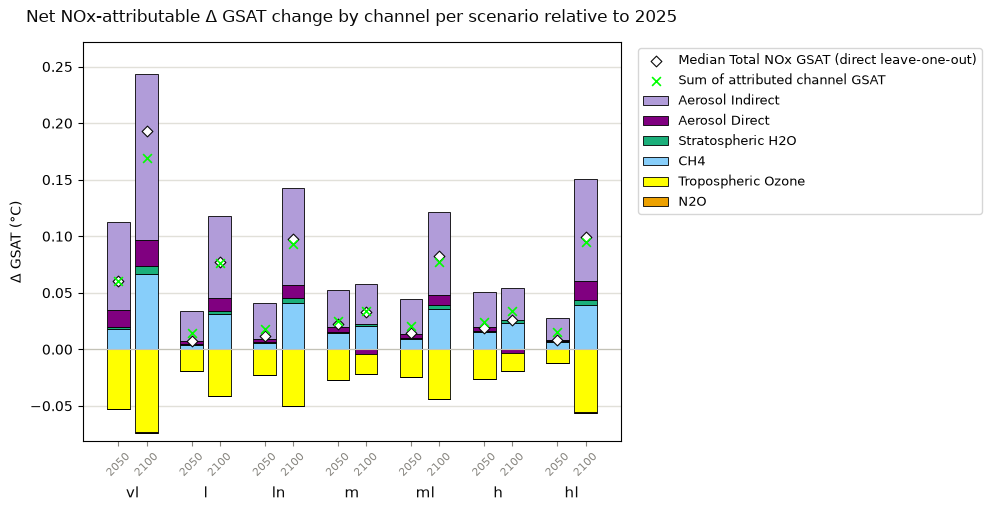

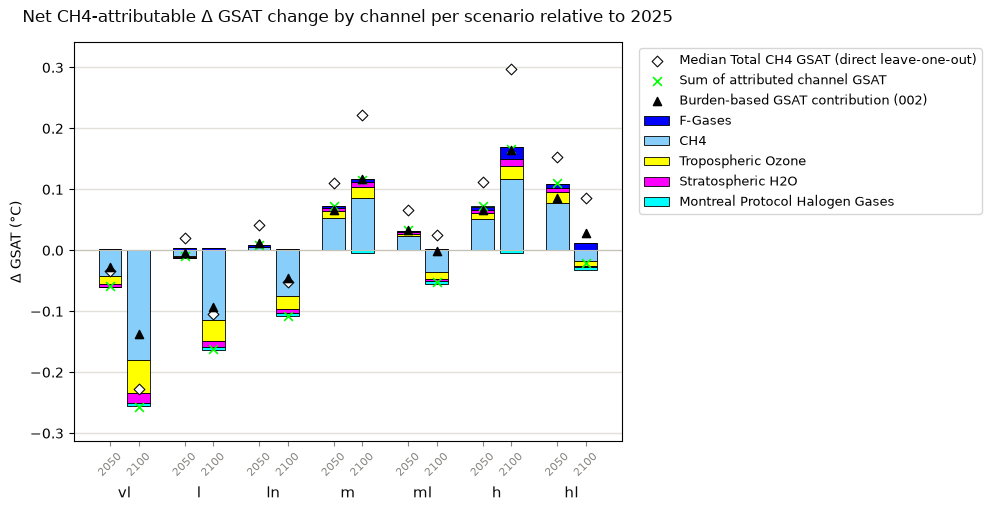

In [9]:
for species_key in SPECIES_CATEGORIES:
    reference_markers_values_delta = species_reference_markers_values_delta[species_key]
    reference_markers_delta = [
        {
            "label": f"Median Total {species_key} GSAT (direct leave-one-out)",
            "values": reference_markers_values_delta["Total species GSAT"],
            "marker": "D",
            "facecolor": ac.COLOR_SURFACE,
            "edgecolor": ac.COLOR_PRIMARY_TEXT,
            "size": 30,
            "linewidths": 0.8,
        },
        {
            "label": "Sum of attributed channel GSAT",
            "values": reference_markers_values_delta["Sum of attributed"],
            "marker": "x",
            "color": "lime",
            "size": 40,
            "linewidths": 1.2,
        },
    ]
    if species_key in BURDEN_AVAILABLE_CHANNEL:
        reference_markers_delta.append(
            {
                "label": "Burden-based GSAT contribution (002)",
                "values": reference_markers_values_delta["Burden-based total"],
                "marker": "^",
                "color": "black",
                "size": 35,
                "linewidths": 1.0,
            }
        )

    out_path_delta = (
        PLOTS_DIR
        / f"{OUTPUT_PREFIX}emissions_{ac.slugify(species_key)}_by_channel_gsat_delta_2025_{'_'.join(str(y) for y in YEARS_TO_PLOT)}.png"
    )
    fig, ax = ac.plot_scenario_year_stacked_bars(
        bucket_values=species_bucket_values_delta[species_key],
        bucket_colors=BUCKET_COLORS[species_key],
        reference_markers=reference_markers_delta,
        scenario_order=scenario_order,
        years=YEARS_TO_PLOT,
        title=rf"Net {species_key}-attributable $\Delta$ GSAT change by channel per scenario relative to 2025",
        ylabel=r"$\Delta$ GSAT (°C)",
        out_path=out_path_delta,
    )
    fix_mixed_sign_legend_order(
        fig, ax, BUCKET_COLORS[species_key], species_bucket_values_delta[species_key], reference_markers_delta, out_path_delta
    )